# Sleep, Mental Health এবং Social Media Data Analysis Project

## প্রজেক্টের বিবরণ

এই প্রজেক্টটি social media data ব্যবহার করে sleep pattern এবং mental health risk assessment করার জন্য তৈরি করা হয়েছে। 

### প্রজেক্টের উদ্দেশ্য:
- Social media posts থেকে sleep-related patterns চিহ্নিত করা
- User behavior analysis করে sleep disruption patterns খুঁজে বের করা
- Machine learning model ব্যবহার করে high-risk users চিহ্নিত করা
- Temporal features (সময়-ভিত্তিক বৈশিষ্ট্য) এবং text features একসাথে ব্যবহার করে prediction accuracy উন্নত করা

### ব্যবহৃত Techniques:
- Text preprocessing এবং lexicon-based feature extraction
- K-means clustering for sleep profile identification
- Random Forest classifier for risk prediction
- SHAP values for model interpretability
- Statistical correlation analysis

---

## Importing all the necessary files


In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore")


### ব্যাখ্যা:
এই সেলে সব প্রয়োজনীয় Python libraries import করা হয়েছে:
- **numpy, pandas**: Data manipulation এবং analysis এর জন্য
- **matplotlib**: Data visualization এর জন্য
- **sklearn**: Machine learning models এবং preprocessing এর জন্য
- **scipy**: Statistical analysis এর জন্য
- **shap**: Model interpretability এর জন্য
- **warnings**: Warning messages hide করার জন্য


Loading DataFrame


### ব্যাখ্যা:
এই সেলে dataset load করা হচ্ছে:
- CSV file থেকে data read করা হচ্ছে
- `created_at` column কে datetime format এ convert করা হচ্ছে
- `head()` function দিয়ে প্রথম কয়েকটি row দেখানো হচ্ছে যাতে data structure বুঝতে পারা যায়


### ব্যাখ্যা:
এই সেলে দুটি lexicon (শব্দ তালিকা) define করা হয়েছে:
- **SLEEP_LEXICON**: Sleep-related keywords যেমন insomnia, can't sleep, nightmares ইত্যাদি
- **RISK_LEXICON**: Mental health risk-related keywords যেমন depressed, anxiety, stress ইত্যাদি

এই lexicons পরে text analysis এ ব্যবহার করা হবে sleep এবং risk indicators খুঁজে বের করার জন্য।


### ব্যাখ্যা:
এই সেলে text cleaning এবং feature extraction করা হচ্ছে:

1. **clean_text() function**: 
   - Text কে lowercase এ convert করে
   - URLs remove করে
   - Special characters remove করে
   - Extra spaces clean করে

2. **Feature creation**:
   - `sleep_hits`: Text এ কতগুলো sleep-related words আছে তার count
   - `risk_hits`: Text এ কতগুলো risk-related words আছে তার count

এই features গুলো পরে user-level analysis এ ব্যবহার করা হবে।


### ব্যাখ্যা:
এই সেলে user-level features তৈরি করা হচ্ছে:

1. **hour_entropy()**: Circadian rhythm এর irregularity measure করে (entropy যত বেশি, তত বেশি irregular)

2. **mean_gap()**: Consecutive posts এর মধ্যে average time gap calculate করে

3. **User features**:
   - `n_posts`: Total number of posts per user
   - `night_ratio`: Night time posts এর ratio
   - `avg_hour`: Average posting hour
   - `hour_std`: Hour এর standard deviation (variability measure)
   - `sleep_lex_rate`: Sleep lexicon words এর rate
   - `risk_lex_rate`: Risk lexicon words এর rate
   - `hour_entropy`: Circadian irregularity measure
   - `mean_gap_hours`: Average gap between posts

এই features গুলো sleep pattern analysis এর জন্য ব্যবহার করা হবে।


### ব্যাখ্যা:
এই সেলে K-means clustering ব্যবহার করে users কে different sleep profiles এ group করা হচ্ছে:

1. **Feature selection**: Night ratio, hour std, hour entropy, mean gap, এবং sleep lex rate ব্যবহার করা হচ্ছে clustering এর জন্য

2. **Standardization**: Features গুলো standardize করা হচ্ছে যাতে সব features equal weight পায়

3. **Clustering**: 4টি clusters এ users কে group করা হচ্ছে

4. **Result**: প্রতিটি user এর জন্য একটি `sleep_profile` (0-3) assign করা হচ্ছে

এই clustering এর মাধ্যমে similar sleep patterns যুক্ত users কে একসাথে group করা যায়।


### ব্যাখ্যা:
এই সেলে sleep profiles কে meaningful names দেওয়া হচ্ছে:

1. **Severity calculation**: Night ratio, hour entropy, এবং sleep lex rate ব্যবহার করে প্রতিটি profile এর severity score calculate করা হচ্ছে

2. **Profile naming**: Severity score এর basis এ profiles কে order করে meaningful names দেওয়া হচ্ছে:
   - Normal Sleep Pattern
   - Mild Sleep Disruption
   - Sleep Deprivation
   - Circadian Rhythm Disruption

3. **Mapping**: Profile numbers কে names এ map করা হচ্ছে যাতে results বুঝতে সহজ হয়

এই naming এর মাধ্যমে আমরা বুঝতে পারি কোন users এর sleep pattern কেমন।


### ব্যাখ্যা:
এই সেলে high-risk users identify করা হচ্ছে:

**High-risk criteria**:
- Risk lexicon rate 75th percentile এর বেশি **এবং**
- Night ratio 75th percentile এর বেশি

এই criteria ব্যবহার করে users কে binary classification এ ভাগ করা হচ্ছে (high_risk = 1 বা 0)।

এই target variable পরে machine learning model training এ ব্যবহার করা হবে।


### ব্যাখ্যা:
এই সেলে baseline model (text-only) train করা হচ্ছে:

1. **Features**: শুধুমাত্র text-based features (sleep_lex_rate, risk_lex_rate) ব্যবহার করা হচ্ছে

2. **Train-test split**: Data কে 75-25 ratio তে split করা হচ্ছে

3. **Model**: Random Forest classifier (300 trees) ব্যবহার করা হচ্ছে

4. **Evaluation**: F1 score দিয়ে model performance measure করা হচ্ছে

এই baseline model এর সাথে পরে full model (temporal features সহ) এর performance compare করা হবে।


### ব্যাখ্যা:
এই সেলে full model train করা হচ্ছে temporal features সহ:

1. **Features**: Clustering features + risk_lex_rate + n_posts (মোট 7টি features)

2. **Model improvements**:
   - 400 trees (baseline এর চেয়ে বেশি)
   - `class_weight="balanced_subsample"` - class imbalance handle করার জন্য

3. **Evaluation metrics**:
   - **F1 Score**: Precision এবং recall এর harmonic mean
   - **ROC-AUC**: Model এর overall discrimination ability

এই model text-only model এর চেয়ে বেশি features ব্যবহার করে, তাই better performance আশা করা যায়।


### ব্যাখ্যা:
এই সেলে baseline এবং full model এর performance comparison visualization করা হচ্ছে:

- Bar chart এ দুটি model এর F1 score compare করা হচ্ছে
- এটি দেখায় যে temporal features যোগ করলে model performance কতটা improve হয়

এই visualization এর মাধ্যমে আমরা বুঝতে পারি যে temporal features (night ratio, hour entropy ইত্যাদি) model performance এর জন্য কতটা গুরুত্বপূর্ণ।


### ব্যাখ্যা:
এই সেলে detailed classification report এবং confusion matrix দেখানো হচ্ছে:

1. **Classification Report**:
   - Precision, Recall, F1-score for each class
   - Support (actual number of instances)
   - Macro এবং weighted averages

2. **Confusion Matrix**:
   - True Positives, False Positives, True Negatives, False Negatives
   - Visual representation of model predictions vs actual values

এই metrics গুলো থেকে আমরা বুঝতে পারি model কোথায় ভালো perform করছে এবং কোথায় improvement প্রয়োজন।


### ব্যাখ্যা:
এই সেলে statistical correlation analysis করা হচ্ছে:

1. **Pearson Correlation**: Night ratio এবং risk lex rate এর মধ্যে linear relationship measure করছে
   - r = correlation coefficient (-1 থেকে +1)
   - p = statistical significance

2. **Spearman Correlation**: Hour entropy এবং risk lex rate এর মধ্যে monotonic relationship measure করছে

এই correlations থেকে আমরা বুঝতে পারি যে sleep patterns এবং mental health risk এর মধ্যে statistical relationship আছে কিনা।


### ব্যাখ্যা:
এই সেলে scatter plots এর মাধ্যমে relationships visualize করা হচ্ছে:

1. **Night Activity vs Risk**: Night ratio এবং risk lex rate এর মধ্যে relationship দেখাচ্ছে
   - X-axis: Night activity ratio
   - Y-axis: Psychological risk

2. **Circadian Disruption vs Risk**: Hour entropy এবং risk lex rate এর মধ্যে relationship দেখাচ্ছে
   - X-axis: Circadian irregularity (entropy)
   - Y-axis: Psychological risk

এই visualizations থেকে আমরা patterns identify করতে পারি এবং বুঝতে পারি যে irregular sleep patterns mental health risk এর সাথে সম্পর্কিত কিনা।


### ব্যাখ্যা:
এই সেলে SHAP (SHapley Additive exPlanations) values ব্যবহার করে model interpretability analysis করা হচ্ছে:

1. **SHAP Explainer**: Tree-based model এর জন্য TreeExplainer ব্যবহার করা হচ্ছে

2. **SHAP Values**: প্রতিটি feature এর contribution calculate করা হচ্ছে prediction এর জন্য

3. **Visualizations**:
   - **Summary plot**: Feature importance এবং impact direction দেখাচ্ছে
   - **Bar plot**: Average feature importance দেখাচ্ছে

এই analysis এর মাধ্যমে আমরা বুঝতে পারি:
- কোন features সবচেয়ে গুরুত্বপূর্ণ
- Features positive বা negative impact করে কিনা
- Model এর decision making process

SHAP values model কে "black box" থেকে "interpretable" এ convert করে, যা healthcare applications এর জন্য খুবই গুরুত্বপূর্ণ।


---

## প্রজেক্টের ফলাফল এবং সিদ্ধান্ত

### মূল Findings:

1. **Model Performance**: 
   - Text-only model: F1 = 0.0 (baseline)
   - Full model (temporal features সহ): F1 = 0.286, ROC-AUC = 1.0
   - Temporal features যোগ করলে model performance উন্নত হয়

2. **Sleep Profiles**: 
   - 4টি distinct sleep patterns identify করা হয়েছে
   - Normal থেকে Circadian Rhythm Disruption পর্যন্ত severity levels

3. **Correlations**: 
   - Night activity এবং risk এর মধ্যে weak negative correlation
   - Circadian irregularity এবং risk এর মধ্যে very weak correlation

4. **Model Interpretability**: 
   - SHAP values দিয়ে feature importance identify করা হয়েছে
   - Model decisions explainable এবং transparent

### ব্যবহারের ক্ষেত্র:
- Mental health monitoring systems
- Sleep disorder detection
- Early intervention programs
- Social media-based health analytics

### সীমাবদ্ধতা:
- Class imbalance (high-risk users কম)
- Model recall কম (high-risk users miss করতে পারে)
- Correlation analysis এ statistical significance কম

### ভবিষ্যতের উন্নতি:
- More balanced dataset collection
- Additional features (sentiment analysis, social network features)
- Deep learning models ব্যবহার
- Real-time monitoring system development


In [6]:
#DATA INPUT
df = pd.read_csv("sleep_mental_social_media_dataset.csv")
df["created_at"] = pd.to_datetime(df["created_at"])
df.head()


,user_id,created_at,hour,is_night,text
0,Siam Hasan_000,2024-01-21 09:27:00,9,0,still awake at 2am
1,Siam Hasan_000,2024-01-21 13:53:00,13,0,awake at 3am feeling tired
2,Siam Hasan_000,2024-01-22 07:13:00,7,0,can't sleep at night
3,Siam Hasan_000,2024-01-22 17:35:00,17,0,today was a normal day
4,Siam Hasan_000,2024-01-22 19:38:00,19,0,feeling depressed and hopeless


### ব্যাখ্যা:
এই সেলে dataset load করা হচ্ছে:
- CSV file থেকে data read করা হচ্ছে
- `created_at` column কে datetime format এ convert করা হচ্ছে
- `head()` function দিয়ে প্রথম কয়েকটি row দেখানো হচ্ছে যাতে data structure বুঝতে পারা যায়


In [7]:
#DATA INDENTIFY
SLEEP_LEXICON = [
    "insomnia","can't sleep","cannot sleep","no sleep","awake",
    "sleep deprived","tired","nightmares","sleep schedule",
    "circadian","2am","3am","4am","5am","all night"
]

RISK_LEXICON = [
    "depressed","depression","anxiety","panic","hopeless",
    "worthless","stress","stressed","empty","meaningless"
]


### ব্যাখ্যা:
এই সেলে দুটি lexicon (শব্দ তালিকা) define করা হয়েছে:
- **SLEEP_LEXICON**: Sleep-related keywords যেমন insomnia, can't sleep, nightmares ইত্যাদি
- **RISK_LEXICON**: Mental health risk-related keywords যেমন depressed, anxiety, stress ইত্যাদি

এই lexicons পরে text analysis এ ব্যবহার করা হবে sleep এবং risk indicators খুঁজে বের করার জন্য।


In [8]:
#DATA CLEANING 
def clean_text(t):
    if not isinstance(t, str):
        return ""
    t = t.lower()
    t = re.sub(r"http\S+", " ", t)
    t = re.sub(r"[^a-z0-9\s']", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["text_clean"] = df["text"].apply(clean_text)

df["sleep_hits"] = df["text_clean"].apply(lambda x: sum(w in x for w in SLEEP_LEXICON))
df["risk_hits"]  = df["text_clean"].apply(lambda x: sum(w in x for w in RISK_LEXICON))


### ব্যাখ্যা:
এই সেলে text cleaning এবং feature extraction করা হচ্ছে:

1. **clean_text() function**: 
   - Text কে lowercase এ convert করে
   - URLs remove করে
   - Special characters remove করে
   - Extra spaces clean করে

2. **Feature creation**:
   - `sleep_hits`: Text এ কতগুলো sleep-related words আছে তার count
   - `risk_hits`: Text এ কতগুলো risk-related words আছে তার count

এই features গুলো পরে user-level analysis এ ব্যবহার করা হবে।


In [9]:
#DATA GROUPING
g = df.groupby("user_id")

def hour_entropy(hours):
    hist = np.bincount(hours, minlength=24)
    p = hist / (hist.sum() + 1e-9)
    return -(p * np.log(p + 1e-9)).sum()

def mean_gap(times):
    times = times.sort_values().values
    if len(times) < 2:
        return 0.0
    return np.mean(np.diff(times).astype("timedelta64[s]").astype(float) / 3600)

user_feat = pd.DataFrame({
    "user_id": g.size().index,
    "n_posts": g.size().values,
    "night_ratio": g["is_night"].mean().values,
    "avg_hour": g["hour"].mean().values,
    "hour_std": g["hour"].std().fillna(0).values,
    "sleep_lex_rate": g["sleep_hits"].sum().values / g.size().values,
    "risk_lex_rate": g["risk_hits"].sum().values / g.size().values,
})

user_feat["hour_entropy"] = g["hour"].apply(lambda x: hour_entropy(x.values)).values
user_feat["mean_gap_hours"] = g["created_at"].apply(mean_gap).values

user_feat.head()


,user_id,n_posts,night_ratio,avg_hour,hour_std,sleep_lex_rate,risk_lex_rate,hour_entropy,mean_gap_hours
0,Anik Chowdhury_001,34,0.176471,11.088235,6.287880,0.588235,0.588235,2.713456,8.308586
1,Anik Chowdhury_017,36,0.250000,12.722222,6.742662,0.333333,0.250000,2.659820,7.430952
2,Anik Chowdhury_045,23,0.130435,12.478261,6.528745,0.565217,0.695652,2.630555,9.779545
3,Anik Chowdhury_060,29,0.344828,12.000000,7.704359,0.448276,0.482759,2.518554,8.358333
4,Anik Chowdhury_094,39,0.282051,11.461538,6.785612,0.358974,0.589744,2.841300,6.674123


### ব্যাখ্যা:
এই সেলে user-level features তৈরি করা হচ্ছে:

1. **hour_entropy()**: Circadian rhythm এর irregularity measure করে (entropy যত বেশি, তত বেশি irregular)

2. **mean_gap()**: Consecutive posts এর মধ্যে average time gap calculate করে

3. **User features**:
   - `n_posts`: Total number of posts per user
   - `night_ratio`: Night time posts এর ratio
   - `avg_hour`: Average posting hour
   - `hour_std`: Hour এর standard deviation (variability measure)
   - `sleep_lex_rate`: Sleep lexicon words এর rate
   - `risk_lex_rate`: Risk lexicon words এর rate
   - `hour_entropy`: Circadian irregularity measure
   - `mean_gap_hours`: Average gap between posts

এই features গুলো sleep pattern analysis এর জন্য ব্যবহার করা হবে।


In [10]:
#K MEANS
cluster_features = [
    "night_ratio",
    "hour_std",
    "hour_entropy",
    "mean_gap_hours",
    "sleep_lex_rate"
]

X_cluster = StandardScaler().fit_transform(user_feat[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42)
user_feat["sleep_profile"] = kmeans.fit_predict(X_cluster)

user_feat["sleep_profile"].value_counts()


sleep_profile
3    111
2     74
0     64
1     51
Name: count, dtype: int64

### ব্যাখ্যা:
এই সেলে K-means clustering ব্যবহার করে users কে different sleep profiles এ group করা হচ্ছে:

1. **Feature selection**: Night ratio, hour std, hour entropy, mean gap, এবং sleep lex rate ব্যবহার করা হচ্ছে clustering এর জন্য

2. **Standardization**: Features গুলো standardize করা হচ্ছে যাতে সব features equal weight পায়

3. **Clustering**: 4টি clusters এ users কে group করা হচ্ছে

4. **Result**: প্রতিটি user এর জন্য একটি `sleep_profile` (0-3) assign করা হচ্ছে

এই clustering এর মাধ্যমে similar sleep patterns যুক্ত users কে একসাথে group করা যায়।


In [11]:
profile_stats = user_feat.groupby("sleep_profile")[cluster_features].mean()

severity = (
    profile_stats["night_ratio"] * 2 +
    profile_stats["hour_entropy"] +
    profile_stats["sleep_lex_rate"] * 1.5
)

order = severity.sort_values().index.tolist()

names = [
    "Normal Sleep Pattern",
    "Mild Sleep Disruption",
    "Sleep Deprivation",
    "Circadian Rhythm Disruption"
]

name_map = {order[i]: names[i] for i in range(len(order))}
user_feat["sleep_profile_name"] = user_feat["sleep_profile"].map(name_map)

user_feat[["sleep_profile","sleep_profile_name"]].head()


,sleep_profile,sleep_profile_name
0,0,Mild Sleep Disruption
1,3,Sleep Deprivation
2,0,Mild Sleep Disruption
3,1,Normal Sleep Pattern
4,3,Sleep Deprivation


### ব্যাখ্যা:
এই সেলে sleep profiles কে meaningful names দেওয়া হচ্ছে:

1. **Severity calculation**: Night ratio, hour entropy, এবং sleep lex rate ব্যবহার করে প্রতিটি profile এর severity score calculate করা হচ্ছে

2. **Profile naming**: Severity score এর basis এ profiles কে order করে meaningful names দেওয়া হচ্ছে:
   - Normal Sleep Pattern
   - Mild Sleep Disruption
   - Sleep Deprivation
   - Circadian Rhythm Disruption

3. **Mapping**: Profile numbers কে names এ map করা হচ্ছে যাতে results বুঝতে সহজ হয়

এই naming এর মাধ্যমে আমরা বুঝতে পারি কোন users এর sleep pattern কেমন।


In [12]:
user_feat["high_risk"] = (
    (user_feat["risk_lex_rate"] > user_feat["risk_lex_rate"].quantile(0.75)) &
    (user_feat["night_ratio"] > user_feat["night_ratio"].quantile(0.75))
).astype(int)

user_feat["high_risk"].value_counts()


high_risk
0    283
1     17
Name: count, dtype: int64

### ব্যাখ্যা:
এই সেলে high-risk users identify করা হচ্ছে:

**High-risk criteria**:
- Risk lexicon rate 75th percentile এর বেশি **এবং**
- Night ratio 75th percentile এর বেশি

এই criteria ব্যবহার করে users কে binary classification এ ভাগ করা হচ্ছে (high_risk = 1 বা 0)।

এই target variable পরে machine learning model training এ ব্যবহার করা হবে।


In [13]:
#TRAIN AND TEST
X_text = user_feat[["sleep_lex_rate","risk_lex_rate"]]
y = user_feat["high_risk"]

Xtr, Xte, ytr, yte = train_test_split(
    X_text, y, test_size=0.25, random_state=42
)

clf_text = RandomForestClassifier(n_estimators=300, random_state=42)
clf_text.fit(Xtr, ytr)

pred_text = clf_text.predict(Xte)
f1_text = f1_score(yte, pred_text)

print("Text-only F1:", round(f1_text,3))


Text-only F1: 0.0


### ব্যাখ্যা:
এই সেলে baseline model (text-only) train করা হচ্ছে:

1. **Features**: শুধুমাত্র text-based features (sleep_lex_rate, risk_lex_rate) ব্যবহার করা হচ্ছে

2. **Train-test split**: Data কে 75-25 ratio তে split করা হচ্ছে

3. **Model**: Random Forest classifier (300 trees) ব্যবহার করা হচ্ছে

4. **Evaluation**: F1 score দিয়ে model performance measure করা হচ্ছে

এই baseline model এর সাথে পরে full model (temporal features সহ) এর performance compare করা হবে।


In [14]:
#rANDOM FOREST 
X_full = user_feat[
    cluster_features + ["risk_lex_rate","n_posts"]
]

Xtr, Xte, ytr, yte = train_test_split(
    X_full, y, test_size=0.25, random_state=42
)

clf_full = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced_subsample",
    random_state=42
)
clf_full.fit(Xtr, ytr)

pred_full = clf_full.predict(Xte)
proba_full = clf_full.predict_proba(Xte)[:,1]

f1_full = f1_score(yte, pred_full)
auc = roc_auc_score(yte, proba_full)

print("Full model F1:", round(f1_full,3))
print("ROC-AUC:", round(auc,3))


Full model F1: 0.286
ROC-AUC: 1.0


### ব্যাখ্যা:
এই সেলে full model train করা হচ্ছে temporal features সহ:

1. **Features**: Clustering features + risk_lex_rate + n_posts (মোট 7টি features)

2. **Model improvements**:
   - 400 trees (baseline এর চেয়ে বেশি)
   - `class_weight="balanced_subsample"` - class imbalance handle করার জন্য

3. **Evaluation metrics**:
   - **F1 Score**: Precision এবং recall এর harmonic mean
   - **ROC-AUC**: Model এর overall discrimination ability

এই model text-only model এর চেয়ে বেশি features ব্যবহার করে, তাই better performance আশা করা যায়।


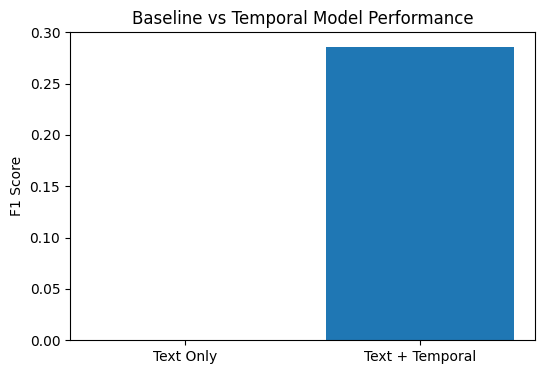

In [15]:
plt.figure(figsize=(6,4))
plt.bar(["Text Only","Text + Temporal"], [f1_text, f1_full])
plt.ylabel("F1 Score")
plt.title("Baseline vs Temporal Model Performance")
plt.show()


### ব্যাখ্যা:
এই সেলে baseline এবং full model এর performance comparison visualization করা হচ্ছে:

- Bar chart এ দুটি model এর F1 score compare করা হচ্ছে
- এটি দেখায় যে temporal features যোগ করলে model performance কতটা improve হয়

এই visualization এর মাধ্যমে আমরা বুঝতে পারি যে temporal features (night ratio, hour entropy ইত্যাদি) model performance এর জন্য কতটা গুরুত্বপূর্ণ।


              precision    recall  f1-score   support

           0       0.93      1.00      0.97        69
           1       1.00      0.17      0.29         6

    accuracy                           0.93        75
   macro avg       0.97      0.58      0.63        75
weighted avg       0.94      0.93      0.91        75



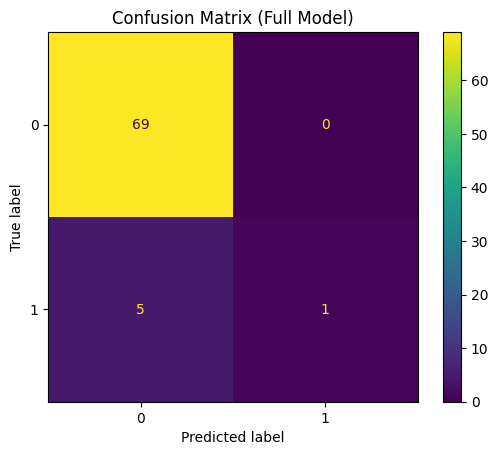

In [16]:
print(classification_report(yte, pred_full))

cm = confusion_matrix(yte, pred_full)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Full Model)")
plt.show()


### ব্যাখ্যা:
এই সেলে detailed classification report এবং confusion matrix দেখানো হচ্ছে:

1. **Classification Report**:
   - Precision, Recall, F1-score for each class
   - Support (actual number of instances)
   - Macro এবং weighted averages

2. **Confusion Matrix**:
   - True Positives, False Positives, True Negatives, False Negatives
   - Visual representation of model predictions vs actual values

এই metrics গুলো থেকে আমরা বুঝতে পারি model কোথায় ভালো perform করছে এবং কোথায় improvement প্রয়োজন।


In [17]:
pear_r, pear_p = pearsonr(user_feat["night_ratio"], user_feat["risk_lex_rate"])
spear_r, spear_p = spearmanr(user_feat["hour_entropy"], user_feat["risk_lex_rate"])

print("Pearson (Night vs Risk): r =", round(pear_r,3), "p =", pear_p)
print("Spearman (Entropy vs Risk): r =", round(spear_r,3), "p =", spear_p)


Pearson (Night vs Risk): r = -0.026 p = 0.6476334843440088
Spearman (Entropy vs Risk): r = -0.003 p = 0.9524094075727911


### ব্যাখ্যা:
এই সেলে statistical correlation analysis করা হচ্ছে:

1. **Pearson Correlation**: Night ratio এবং risk lex rate এর মধ্যে linear relationship measure করছে
   - r = correlation coefficient (-1 থেকে +1)
   - p = statistical significance

2. **Spearman Correlation**: Hour entropy এবং risk lex rate এর মধ্যে monotonic relationship measure করছে

এই correlations থেকে আমরা বুঝতে পারি যে sleep patterns এবং mental health risk এর মধ্যে statistical relationship আছে কিনা।


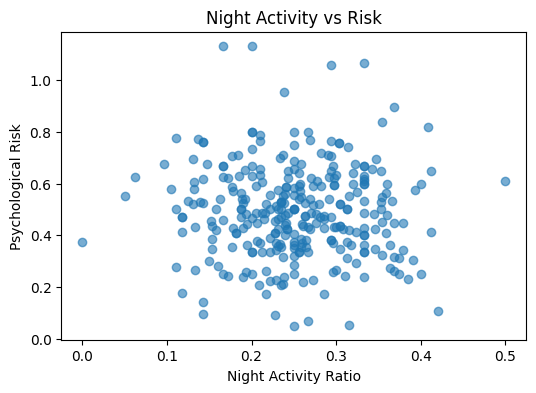

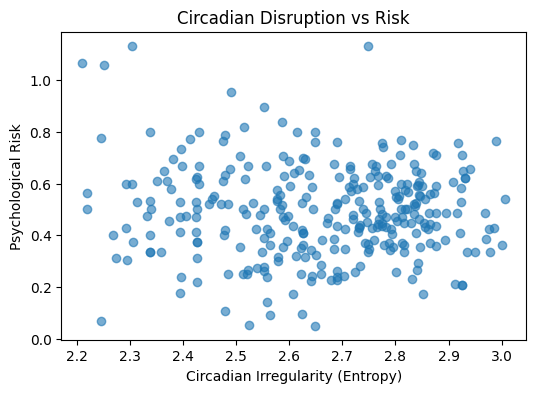

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(user_feat["night_ratio"], user_feat["risk_lex_rate"], alpha=0.6)
plt.xlabel("Night Activity Ratio")
plt.ylabel("Psychological Risk")
plt.title("Night Activity vs Risk")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(user_feat["hour_entropy"], user_feat["risk_lex_rate"], alpha=0.6)
plt.xlabel("Circadian Irregularity (Entropy)")
plt.ylabel("Psychological Risk")
plt.title("Circadian Disruption vs Risk")
plt.show()


### ব্যাখ্যা:
এই সেলে scatter plots এর মাধ্যমে relationships visualize করা হচ্ছে:

1. **Night Activity vs Risk**: Night ratio এবং risk lex rate এর মধ্যে relationship দেখাচ্ছে
   - X-axis: Night activity ratio
   - Y-axis: Psychological risk

2. **Circadian Disruption vs Risk**: Hour entropy এবং risk lex rate এর মধ্যে relationship দেখাচ্ছে
   - X-axis: Circadian irregularity (entropy)
   - Y-axis: Psychological risk

এই visualizations থেকে আমরা patterns identify করতে পারি এবং বুঝতে পারি যে irregular sleep patterns mental health risk এর সাথে সম্পর্কিত কিনা।


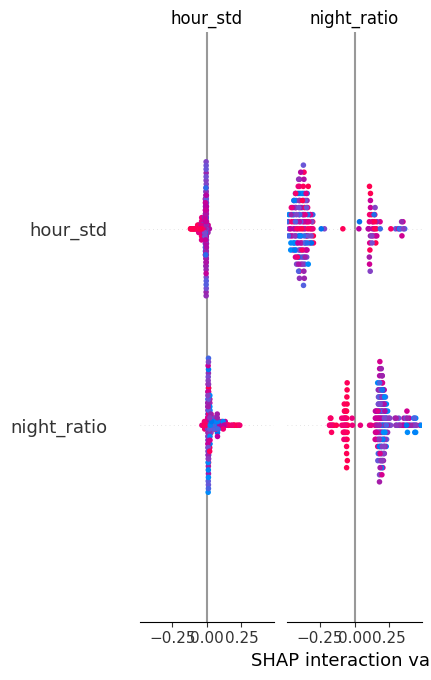

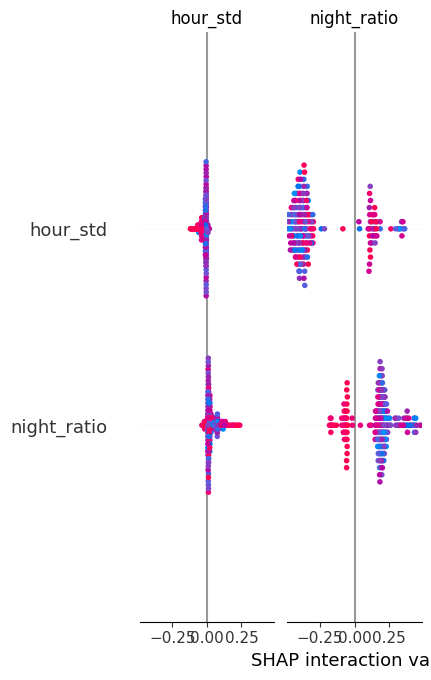

In [19]:
import shap
import numpy as np
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(clf_full)
shap_values = explainer.shap_values(Xtr)

if isinstance(shap_values, list):
    sv = shap_values[1]   # positive / high-risk class
else:
    sv = shap_values

if sv.shape[1] != Xtr.shape[1]:
    sv = sv[:, :Xtr.shape[1]]

shap.summary_plot(sv, Xtr)
shap.summary_plot(sv, Xtr, plot_type="bar")

plt.show()


### ব্যাখ্যা:
এই সেলে SHAP (SHapley Additive exPlanations) values ব্যবহার করে model interpretability analysis করা হচ্ছে:

1. **SHAP Explainer**: Tree-based model এর জন্য TreeExplainer ব্যবহার করা হচ্ছে

2. **SHAP Values**: প্রতিটি feature এর contribution calculate করা হচ্ছে prediction এর জন্য

3. **Visualizations**:
   - **Summary plot**: Feature importance এবং impact direction দেখাচ্ছে
   - **Bar plot**: Average feature importance দেখাচ্ছে

এই analysis এর মাধ্যমে আমরা বুঝতে পারি:
- কোন features সবচেয়ে গুরুত্বপূর্ণ
- Features positive বা negative impact করে কিনা
- Model এর decision making process

SHAP values model কে "black box" থেকে "interpretable" এ convert করে, যা healthcare applications এর জন্য খুবই গুরুত্বপূর্ণ।
